In [1]:
import pandas as pd
import numpy as np
import scipy

In [2]:
df=pd.read_excel(r'/Users/zhangyu/Desktop/统计学算法/独立样本T检验/实验数据.xlsx')

In [3]:
#分组查看均值和标准差
df.groupby('性别')['创新行为'].describe()

,count,mean,std,min,25%,50%,75%,max
性别,,,,,,,,
1,159.0,3.713962,0.732972,1.0,3.17,3.67,4.0,5.0
2,202.0,3.503069,0.744774,1.0,3.00,3.50,4.0,5.0


# 独立样本T检验代码

In [8]:
from scipy.stats import ttest_ind
from scipy.stats import levene
group_1=df[df['性别']==1]['创新行为']
group_2=df[df['性别']==2]['创新行为']
#先做方差是否齐性的检验
stat_levene,p_levene=levene(group_1,group_2)
print(p_levene.round(4))#p=0.9619 说明方差齐性，统计上无显著性差异


0.9619


In [5]:
#t检验
stat,p=ttest_ind(group_1,group_2,equal_var=True)
print(stat,p)
#结果
#t为2.68


2.6895762518608786 0.007488239363436188


# 调参策略

## 原理

方差齐性的统计量表达式

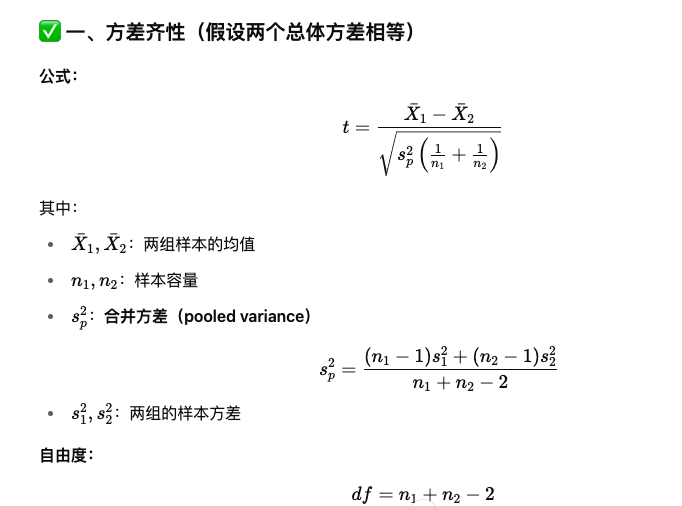

方差非齐性的统计量表达式

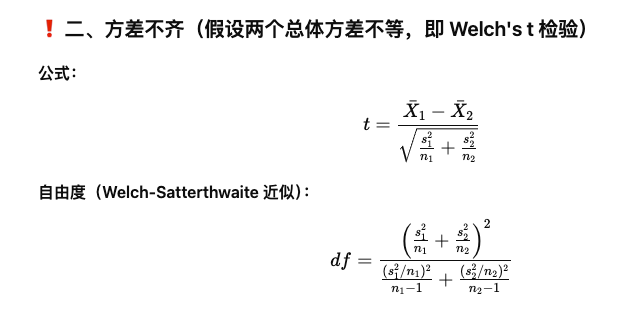

## 调参策略

### 替换样本：增加两个组别的均值差异

In [6]:
#增加两个组别的均值差异
#通过降低group2的均值策略，不新增样本，替换样本
mask=df['性别']==2
n=mask.sum()#组别的2的样本量
group2_adj=df.loc[mask,'创新行为']-np.random.uniform(0.1,0.2,size=n)#生成0.1-0.2的随机数
#方差齐性检验
stat_levene1,p_levene1=levene(group_1,group2_adj)#p=0.89，方差齐性
print(stat_levene1,p_levene1)
t,p=ttest_ind(group_1,group2_adj,equal_var=True)
print(t,p)
#结果
#t

0.00326277668412332 0.9544808094809347
4.601870166328427 5.816611171342294e-06


### 新增样本

In [ ]:
#增加样本,并使新增样本有偏移性，从而增加样本间的均值差异
from numpy import array
def generate_sample(mean,std,n,direction='both',scale=0.5)->array:
    """
    mean:新生成样本的均值基线
    std:加减的标准差
    n:样本数量
    direction:方向，分为up/down/both
    scale:几倍标准差的参数
    """
    if direction=='up':
        low = mean
        high= mean+scale*std
    elif direction=='down':
        low=mean-scale*std
        high=mean
    else:#both
        low=mean-scale*std
        high=mean+scale*std
    return np.random.uniform(low,high,size=n)


In [8]:
n_new=50
#计算原样本的mean std，样本df=n-1
group1_mean,group_1_std=np.mean(group_1),np.std(group_1,ddof=1)
group_2_mean,group_2_std=np.mean(group_2),np.std(group_2,ddof=1)
#生成新样本
new_group1=generate_sample(mean=group1_mean,std=group_1_std,n=n_new,direction='up')
new_group2=generate_sample(mean=group_2_mean,std=group_2_std,n=n_new,direction='down')
#合并样本
group1_merged=np.concatenate([group_1,new_group1])
group2_merged=np.concatenate([group_2,new_group2])

In [9]:
#方差齐性检查
stat_levene1,p_levene1=levene(group1_merged,group2_merged)
print(stat_levene1,p_levene1)#p=0.67方差齐性
t,p=ttest_ind(group1_merged,group2_merged,equal_var=True)
print(t,p)
#结果
#t为4.83，效果显著

0.09458496819374271 0.7585667841866212
4.777392517552454 2.393561493913307e-06


### 降低标准差

In [ ]:
#将1.5倍std外的数据替换为mean+-0.5倍std范围内的随机数
#但是该策略在减小波动差异的同时，也减少了均值差，效果不如前两者

In [5]:
from pandas import Series
def replace_extrame(series:pd.Series,threshold:int,replacement:float,random_state=None)->pd.Series:
    """
    将 series 中超过 mean ± threshold * std 的值，替换为 mean ± replacement * std 范围内的随机数

    参数：
    series:要处理的series
    threshold:异常门槛值
    replacement:替换值/标准差，几倍std
    random_state:随机种子
    """
    rng=np.random.default_rng(random_state)
    mean=series.mean()
    std=series.std()
    uppper=mean+threshold*std
    lower=mean-threshold*std
    
    uppper_new_low=mean
    uppper_new_high=mean+replacement*std
    
    upper_new_low = mean
    upper_new_high = mean + replacement * std
    lower_new_low = mean - replacement * std
    lower_new_high = mean
    
    series_adj = series.copy()

    # 替换上侧极值
    mask_upper = series > uppper
    series_adj[mask_upper] = rng.uniform(upper_new_low, upper_new_high, size=mask_upper.sum())

    # 替换下侧极值
    mask_lower = series < lower
    series_adj[mask_lower] = rng.uniform(lower_new_low, lower_new_high, size=mask_lower.sum())

    return series_adj

In [ ]:

group11=df[df['性别']==1]['创新行为']
group11_replace=replace_extrame(group11,threshold=1.5,replacement=0.5,random_state=1)
group22=df[df['性别']==2]['创新行为']
group22_replace=replace_extrame(group22,threshold=1.5,replacement=0.5,random_state=1)

In [24]:
#检验
stat_levene2,p_levene2=levene(group11_replace,group22_replace)
print(stat_levene2,p_levene2)#p=0.46
t,p=ttest_ind(group11_replace,group22_replace,equal_var=True)
print(t,p)
#结果:t=3.67   

0.5292572060353845 0.46739348545031256
3.6109752594483724 0.0003484480966612933


In [18]:
group11_replace.info()

<class 'pandas.core.series.Series'>
Int64Index: 159 entries, 1 to 360
Series name: 创新行为
Non-Null Count  Dtype  
--------------  -----  
159 non-null    float64
dtypes: float64(1)
memory usage: 2.5 KB
